<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/Googleplaystore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Playstore Case Study
In this module you’ll be learning data visualisation with the help of a case study. This will enable you to understand how visualisation aids you in solving business problems.
**Problem Statement**

The team at Google Play Store wants to develop a feature that would enable them to boost visibility for the most promising apps. Now, this analysis would require a preliminary understanding of the features that define a well-performing app. You can ask questions like:
- Does a higher size or price necessarily mean that an app would perform better than the other apps?
- Or does a higher number of installs give a clear picture of which app would have a better rating than others?


In [ ]:
# Inporting necessary libraries
import numpy as np
import pandas as pd

# Reading your file
data = pd.read_csv("googleplaystore_v2.csv")
data.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [ ]:
# checking size of the table , rows and columns
data.shape

(10841, 13)

In [ ]:
data.isnull()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Bucket,updated_month
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9350,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9351,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9352,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9353,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# checking for null values in rows for each column
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Data Handling and Cleaning
The first few steps involve making sure that there are no __missing values__ or __incorrect data types__ before we proceed to the analysis stage. These aforementioned problems are handled as follows:

 - For Missing Values: Some common techniques to treat this issue are
    - Dropping the rows containing the missing values
    - Imputing the missing values
    - Keep the missing values if they don't affect the analysis

    
 - Incorrect Data Types:
    - Clean certain values
    - Clean and convert an entire column



In [ ]:
# data types in each columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  float64
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.1+ MB


In [ ]:
data = data[-data.Rating.isnull()]

Handling missing values for rating
 - Ratings is the target variable
 - drop the records

In [ ]:
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       4
Android Ver       3
dtype: int64

In [ ]:
data.shape

(9367, 13)

In [ ]:
data[data['Android Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.000000,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.000000,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,21516.529524,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [ ]:
# row is having shifted values so will drop row no 10472
data.loc[10472,:]
data[(data["Android Ver"].isnull() & (data.Category == "1.9"))]
data = data[-(data["Android Ver"].isnull() & (data.Category == "1.9"))]

In [ ]:
data[data['Android Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.0,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.0,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN


In [ ]:
data['Android Ver'].value_counts()

4.1 and up            2059
Varies with device    1319
4.0.3 and up          1240
4.0 and up            1131
4.4 and up             875
2.3 and up             582
5.0 and up             535
4.2 and up             338
2.3.3 and up           240
3.0 and up             211
2.2 and up             208
4.3 and up             207
2.1 and up             113
1.6 and up              87
6.0 and up              48
7.0 and up              41
3.2 and up              31
2.0 and up              27
5.1 and up              18
1.5 and up              16
3.1 and up               8
2.0.1 and up             7
4.4W and up              6
8.0 and up               5
7.1 and up               3
4.0.3 - 7.1.1            2
5.0 - 8.0                2
1.0 and up               2
7.0 - 7.1.1              1
4.1 - 7.1.1              1
5.0 - 6.0                1
Name: Android Ver, dtype: int64

Imputing Missing Values

- For numerical variables use mean and median
- For categorical variables use mode

In [ ]:
# Impute missing values in android version
data['Android Ver'] = data['Android Ver'].fillna(data['Android Ver'].mode()[0])

In [ ]:
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       4
Android Ver       0
dtype: int64

In [ ]:
data[data['Current Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2700.0,"5,000+",Free,0,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145,11.0,"1,000,000+",Free,0,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010,8700.0,"500,000+",Free,0,Everyone,Tools,"May 10, 2017",NaN,4.0 and up
7333,Dots puzzle,FAMILY,4.0,179,14000.0,"50,000+",Paid,$0.99,Everyone,Puzzle,"April 18, 2018",NaN,4.0 and up


In [ ]:
data['Current Ver'].value_counts()

Varies with device    1415
1.0                    458
1.1                    195
1.2                    126
1.3                    120
                      ... 
2.9.10                   1
3.18.5                   1
1.3.A.2.9                1
9.9.1.1910               1
0.3.4                    1
Name: Current Ver, Length: 2638, dtype: int64

In [ ]:
data['Current Ver'] = data['Current Ver'].fillna(data['Current Ver'].mode()[0])
# mode = maximum no of rows that are repeated

In [ ]:
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [ ]:
##### Handling Incorrect Data Types
data.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size              float64
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [ ]:
data.Price.value_counts()

0          8719
$2.99       114
$0.99       107
$4.99        70
$1.99        59
           ... 
$1.29         1
$299.99       1
$379.99       1
$37.99        1
$1.20         1
Name: Price, Length: 73, dtype: int64

In [ ]:
# convert Price column from text to interger or float
data.Price = data.Price.apply(lambda x: 0 if x == '0' else float(x[1:]))

In [ ]:
data.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size              float64
Installs           object
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [ ]:
data.Reviews.value_counts()

2         83
3         78
4         74
5         74
1         67
          ..
49657      1
41420      1
7146       1
44706      1
398307     1
Name: Reviews, Length: 5992, dtype: int64

In [ ]:
data.Reviews = data.Reviews.astype("int32")

In [ ]:
data.dtypes

App                object
Category           object
Rating            float64
Reviews             int32
Size              float64
Installs           object
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [ ]:
data.Reviews.describe() # describe function gives you the statitics of that table or column
# mean or average =  Sum of all valuesin the column / Total no of rows.


count    9.366000e+03
mean     5.140498e+05
std      3.144042e+06
min      1.000000e+00
25%      1.862500e+02
50%      5.930500e+03
75%      8.153275e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [ ]:
data.describe()

,Rating,Reviews,Size,Price
count,9366.000000,9.366000e+03,9366.000000,9366.000000
mean,4.191757,5.140498e+05,22705.733753,0.960928
std,0.515219,3.144042e+06,21305.040123,15.816585
min,1.000000,1.000000e+00,8.500000,0.000000
25%,4.000000,1.862500e+02,6600.000000,0.000000
50%,4.300000,5.930500e+03,21000.000000,0.000000
75%,4.500000,8.153275e+04,27000.000000,0.000000
max,5.000000,7.815831e+07,100000.000000,400.000000


In [ ]:
data.Installs.value_counts()

1,000,000+        1577
10,000,000+       1252
100,000+          1150
10,000+           1010
5,000,000+         752
1,000+             713
500,000+           538
50,000+            467
5,000+             432
100,000,000+       409
100+               309
50,000,000+        289
500+               201
500,000,000+        72
10+                 69
1,000,000,000+      58
50+                 56
5+                   9
1+                   3
Name: Installs, dtype: int64

In [ ]:
# cleaning of Installs column

def clean_installs(val):

    return int(val.replace(",","").replace("+",""))
type(clean_installs("3,000+"))

data.Installs = data.Installs.apply(clean_installs)



In [ ]:
data.Installs.value_counts()

1000000       1577
10000000      1252
100000        1150
10000         1010
5000000        752
1000           713
500000         538
50000          467
5000           432
100000000      409
100            309
50000000       289
500            201
500000000       72
10              69
1000000000      58
50              56
5                9
1                3
Name: Installs, dtype: int64

In [ ]:
data.describe()

,Rating,Reviews,Size,Installs,Price
count,9366.000000,9.366000e+03,9366.000000,9.366000e+03,9366.000000
mean,4.191757,5.140498e+05,22705.733753,1.789744e+07,0.960928
std,0.515219,3.144042e+06,21305.040123,9.123822e+07,15.816585
min,1.000000,1.000000e+00,8.500000,1.000000e+00,0.000000
25%,4.000000,1.862500e+02,6600.000000,1.000000e+04,0.000000
50%,4.300000,5.930500e+03,21000.000000,5.000000e+05,0.000000
75%,4.500000,8.153275e+04,27000.000000,5.000000e+06,0.000000
max,5.000000,7.815831e+07,100000.000000,1.000000e+09,400.000000


In [ ]:
data.dtypes

App                object
Category           object
Rating            float64
Reviews             int32
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [ ]:
# Some more sanity check
#The data that we have needs to make sense and therefore you can perform certain sanity checks on them to ensure they are factually correct as well. Some sanity checks can be:

# 1)Ratings should be between 1 to 5
# 2) Reviews should be less than or equal to Install
# 3) Free Apps should show 0 in Price columns

data[data.Reviews > data.Installs].shape

(7, 13)

In [ ]:
data[(data.Type == "Free") & (data.Price>0)].shape

(0, 13)

In [ ]:
data.Rating.describe() # Rating of the apps is between 1 to 5

count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [ ]:
data[data['Reviews'] > data['Installs']]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2454,KBA-EZ Health Guide,MEDICAL,5.0,4,25000.000000,1,Free,0.00,Everyone,Medical,"August 2, 2018",1.0.72,4.0.3 and up
4663,Alarmy (Sleep If U Can) - Pro,LIFESTYLE,4.8,10249,21516.529524,10000,Paid,2.49,Everyone,Lifestyle,"July 30, 2018",Varies with device,Varies with device
5917,Ra Ga Ba,GAME,5.0,2,20000.000000,1,Paid,1.49,Everyone,Arcade,"February 8, 2017",1.0.4,2.3 and up
6700,Brick Breaker BR,GAME,5.0,7,19000.000000,5,Free,0.00,Everyone,Arcade,"July 23, 2018",1.0,4.1 and up
7402,Trovami se ci riesci,GAME,5.0,11,6100.000000,10,Free,0.00,Everyone,Arcade,"March 11, 2017",0.1,2.3 and up
8591,DN Blog,SOCIAL,5.0,20,4200.000000,10,Free,0.00,Teen,Social,"July 23, 2018",1.0,4.0 and up
10697,Mu.F.O.,GAME,5.0,2,16000.000000,1,Paid,0.99,Everyone,Arcade,"March 3, 2017",1.0,2.3 and up


In [ ]:
condition = data['Reviews'] > data['Installs']
data = data.drop(data[condition].index)
data.shape

(9359, 13)

In [ ]:
data[data['Reviews'] > data['Installs']].shape

(0, 13)

In [ ]:
# Univariate Analysis
import matplotlib.pyplot as plt
import seaborn as sns


#### Outliers Analysis Using Boxplot
Now you need to start identifying and removing extreme values or __outliers__ from our dataset. These values can tilt our analysis and often provide us with a biased perspective of the data available. This is where you’ll start utilising visualisation to achieve your tasks. And the best visualisation to use here would be the box plot. Boxplots are one of the best ways of analysing the spread of a numeric variable


Using a box plot you can identify the outliers as follows:

- Outliers in data can arise due to genuine reasons or because of dubious entries. In the latter case, you should go ahead and remove such entries immediately. Use a boxplot to observe, analyse and remove them.
- In the former case, you should determine whether or not removing them would add value to your analysis procedure.
- You can create a box plot directly from pandas dataframe or the matplotlib way as you learnt in the previous session. Check out their official documentation here:
   - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html
   - https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.boxplot.html

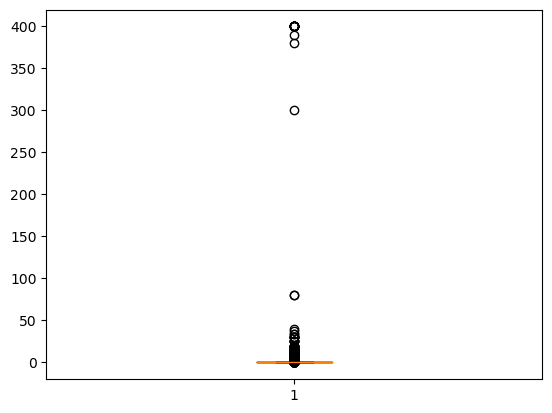

In [ ]:
plt.boxplot(data.Price)
plt.show()

In [ ]:
data[data.Price>200].describe()


,Rating,Reviews,Size,Installs,Price
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,3.866667,603.266667,8904.333333,14606.666667,391.324000
std,0.381101,943.841729,11580.105919,26563.521353,25.875398
min,2.900000,6.000000,965.000000,100.000000,299.990000
25%,3.700000,111.000000,2650.000000,1000.000000,399.990000
50%,3.800000,217.000000,3800.000000,5000.000000,399.990000
75%,4.100000,595.000000,8000.000000,10000.000000,399.990000
max,4.400000,3547.000000,41000.000000,100000.000000,400.000000


In [ ]:
data[data.Price<200].describe()

,Rating,Reviews,Size,Installs,Price
count,9344.000000,9.344000e+03,9344.000000,9.344000e+03,9344.000000
mean,4.191695,5.152581e+05,22732.932449,1.793956e+07,0.334463
std,0.515004,3.147643e+06,21316.475007,9.134144e+07,2.169925
min,1.000000,1.000000e+00,8.500000,5.000000e+00,0.000000
25%,4.000000,1.880000e+02,6600.000000,1.000000e+04,0.000000
50%,4.300000,5.998500e+03,21000.000000,5.000000e+05,0.000000
75%,4.500000,8.222650e+04,27000.000000,5.000000e+06,0.000000
max,5.000000,7.815831e+07,100000.000000,1.000000e+09,79.990000


In [ ]:
data.Price.describe()

count    9359.000000
mean        0.961116
std        15.822478
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

<Axes: >

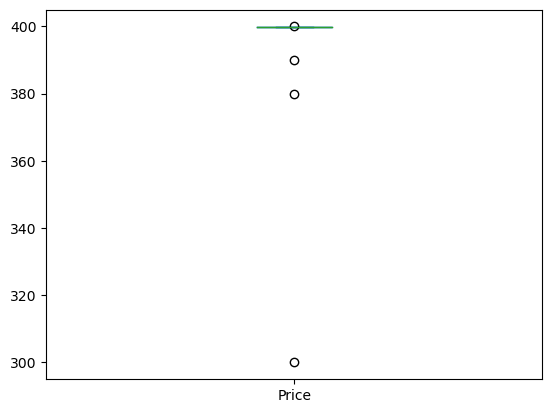

In [ ]:
data[data.Price>200].Price.plot.box()

<Axes: >

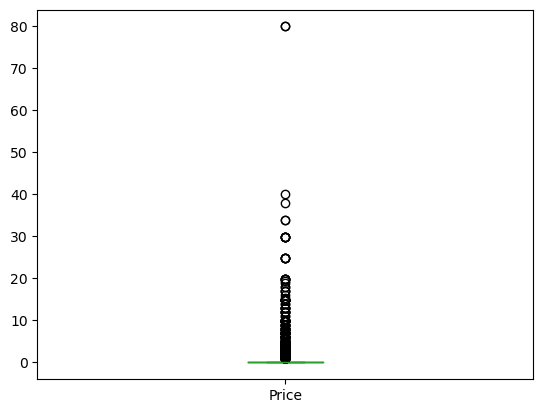

In [ ]:
data[data.Price<200].Price.plot.box()

In [ ]:
data[data.Price>30].shape

(21, 13)

In [ ]:
data[data.Price>30].describe()

,Rating,Reviews,Size,Installs,Price
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,3.923810,466.714286,16031.666667,10676.190476,294.085714
std,0.414614,821.064135,21178.196532,23119.708146,159.424893
min,2.900000,6.000000,965.000000,100.000000,33.990000
25%,3.600000,92.000000,2600.000000,1000.000000,79.990000
50%,4.000000,201.000000,4700.000000,1000.000000,399.990000
75%,4.200000,411.000000,26000.000000,10000.000000,399.990000
max,4.600000,3547.000000,68000.000000,100000.000000,400.000000


In [ ]:
data[data.Price<=30].shape

(9338, 13)

In [ ]:
data[data.Price<=30].describe()

,Rating,Reviews,Size,Installs,Price
count,9338.000000,9.338000e+03,9338.000000,9.338000e+03,9338.000000
mean,4.191776,5.155891e+05,22725.789334,1.795108e+07,0.301915
std,0.515031,3.148627e+06,21310.340299,9.136965e+07,1.669887
min,1.000000,1.000000e+00,8.500000,5.000000e+00,0.000000
25%,4.000000,1.890000e+02,6600.000000,1.000000e+04,0.000000
50%,4.300000,6.011500e+03,21000.000000,5.000000e+05,0.000000
75%,4.500000,8.247100e+04,27000.000000,5.000000e+06,0.000000
max,5.000000,7.815831e+07,100000.000000,1.000000e+09,29.990000


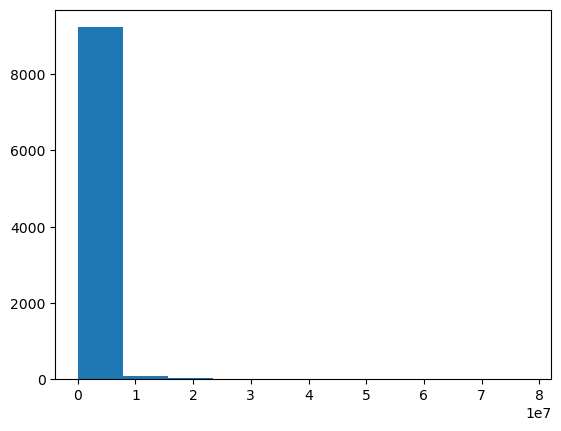

In [ ]:
plt.hist(data.Reviews)
plt.show()

### Histograms

Histograms can also be used in conjuction with boxplots for data cleaning and data handling purposes. You can use it to check the spread of a numeric variable. Histograms generally work by bucketing the entire range of values that a particular variable takes to specific __bins__. After that, it uses vertical bars to denote the total number of records in a specific bin, which is also known as its __frequency__.
You can adjust the number of bins to improve its granularity

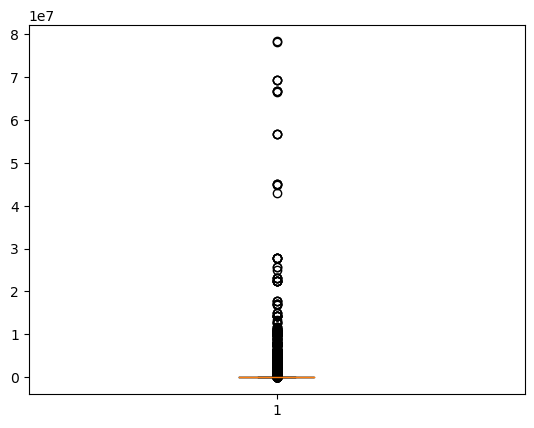

In [ ]:
plt.boxplot(data.Reviews)
plt.show()

In [ ]:
data[data.Reviews>=10000000].shape

(92, 13)

In [ ]:
data[data.Reviews<=10000000].shape

(9267, 13)

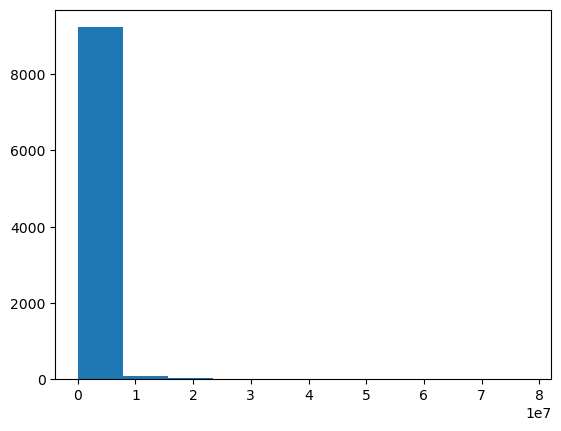

In [ ]:
plt.hist(data.Reviews)
plt.show()

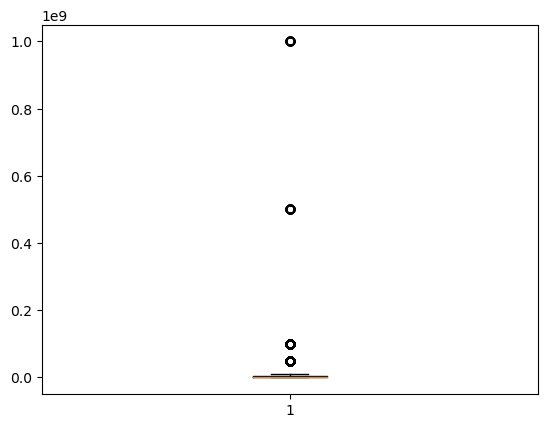

In [ ]:
plt.boxplot(data.Installs)
plt.show()

In [ ]:
data.Installs.describe()

count    9.359000e+03
mean     1.791083e+07
std      9.127102e+07
min      5.000000e+00
25%      1.000000e+04
50%      5.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [ ]:
data[data.Installs <= 10000000].shape

(8531, 13)

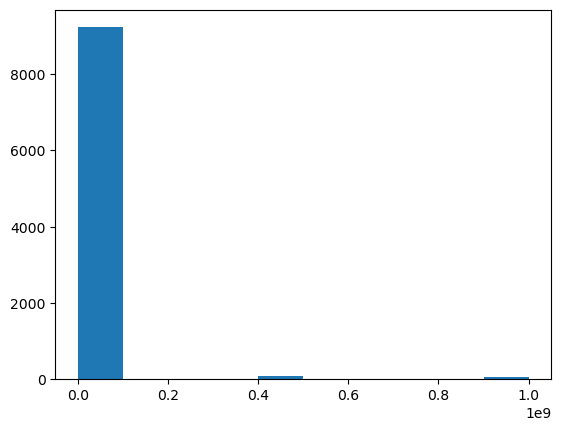

In [ ]:
plt.hist(data.Installs)
plt.show()

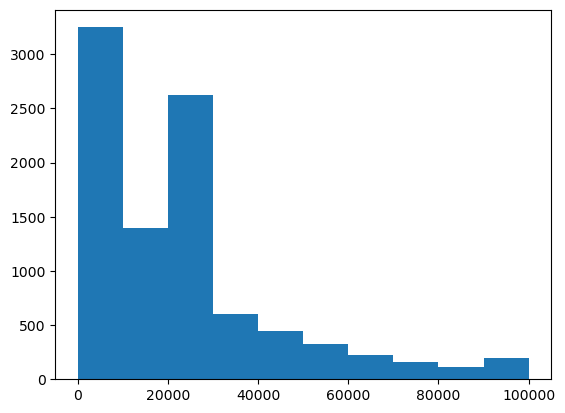

In [ ]:
plt.hist(data.Size)
plt.show()

In [ ]:
data.Size.describe()

count      9359.000000
mean      22710.768864
std       21311.274234
min           8.500000
25%        6600.000000
50%       21000.000000
75%       27000.000000
max      100000.000000
Name: Size, dtype: float64

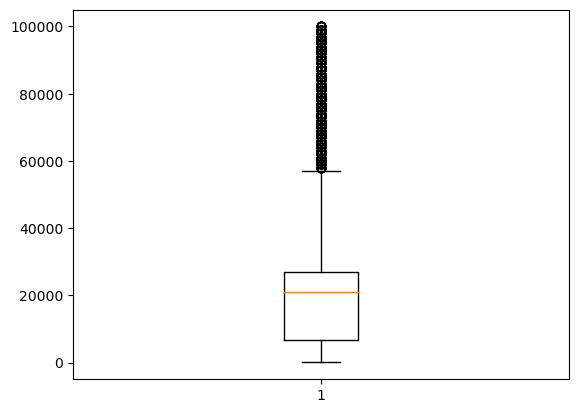

In [ ]:
plt.boxplot(data.Size)
plt.show()

In [ ]:
import seaborn as sns
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

Seaborn is Python library to create statistical graphs easily. It is built on top of matplotlib and closely integrated with pandas.

_Functionalities of Seaborn_ :

- Dataset oriented API
- Analysing univariate and bivariate distributions
- Automatic estimation and plotting of  linear regression models
- Convenient views for complex datasets
- Concise control over style
- Colour palettes


In [ ]:
import warnings
warnings.filterwarnings("ignore")

A distribution plot is pretty similar to the histogram functionality in matplotlib. Instead of a frequency plot, it plots an approximate probability density for that rating bucket. And the curve (or the __KDE__) that gets drawn over the distribution is the approximate probability density curve.


You'll be using sns.distplot for plotting a distribution plot. Check out its official documentation: https://seaborn.pydata.org/generated/seaborn.distplot.html

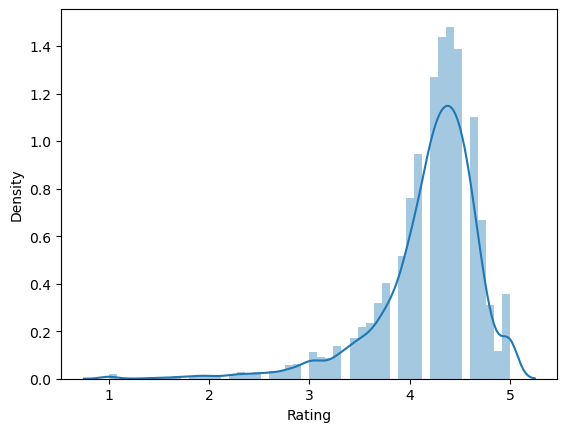

In [ ]:
sns.distplot(data.Rating)
plt.show()

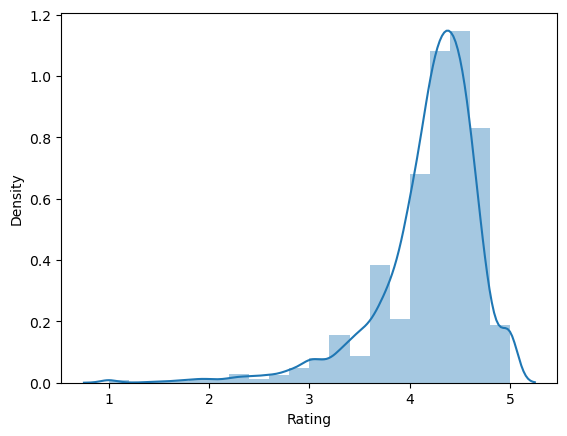

In [ ]:
sns.distplot(data.Rating, bins = 20)
plt.show()

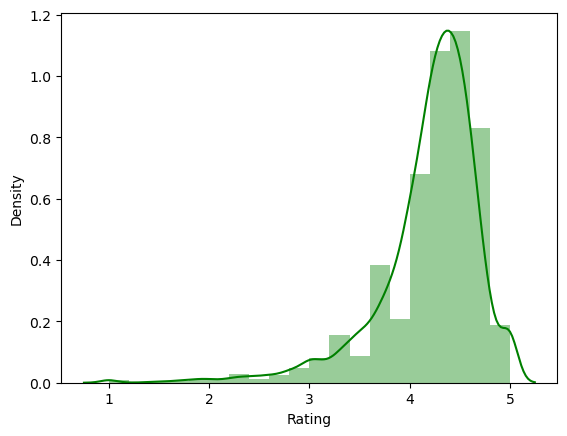

In [ ]:
sns.distplot(data.Rating, bins = 20, color = 'g')
plt.show()

#### Styling Options

One of the biggest advantages of using Seaborn is that you can retain its aesthetic properties and also the Matplotlib functionalities to perform additional customisations. Before we continue with our case study analysis, let’s study some styling options that are available in Seaborn. -  Check out the official documentation:https://seaborn.pydata.org/generated/seaborn.set_style.html

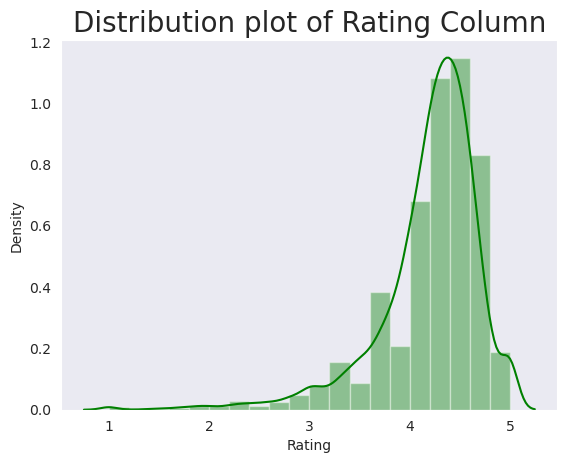

In [ ]:
sns.set_style
sns.set_style("dark")
sns.distplot(data.Rating, bins = 20, color = 'g')
plt.title("Distribution plot of Rating Column", fontsize = 20)
plt.show()

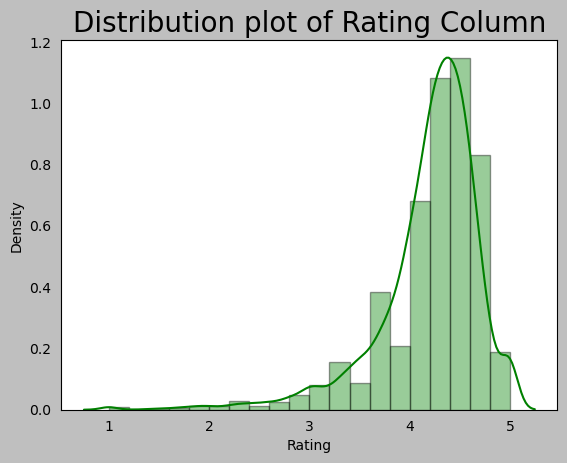

In [ ]:
plt.style.use("grayscale")
#sns.set_style("tableau-colorblind10")
sns.distplot(data.Rating, bins = 20, color = 'g')
plt.title("Distribution plot of Rating Column", fontsize = 20)
plt.show()

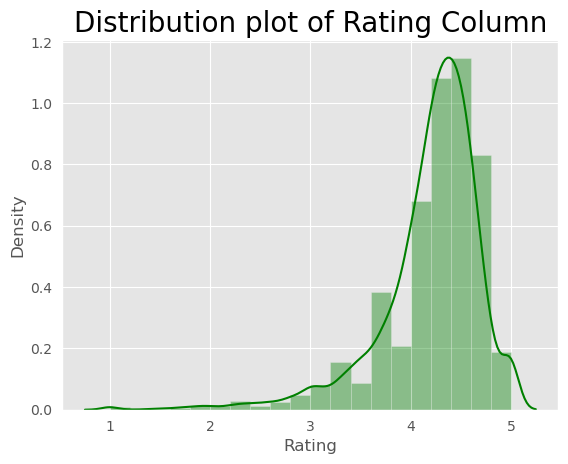

In [ ]:
plt.style.use("ggplot")
#sns.set_style("tableau-colorblind10")
sns.distplot(data.Rating, bins = 20, color = 'g')
plt.title("Distribution plot of Rating Column", fontsize = 20)
plt.show()

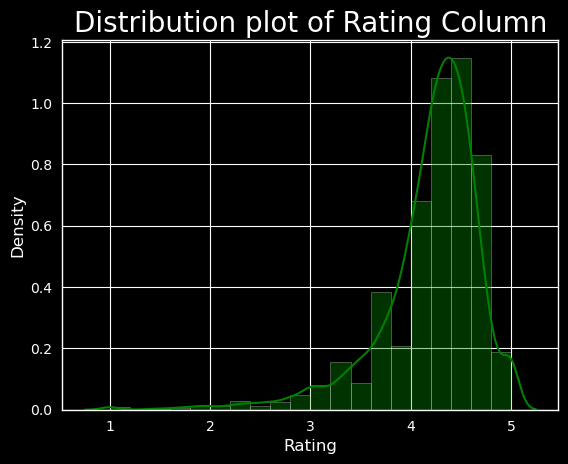

In [ ]:
plt.style.use("dark_background")
#sns.set_style("tableau-colorblind10")
sns.distplot(data.Rating, bins = 20, color = 'g')
plt.title("Distribution plot of Rating Column", fontsize = 20)
plt.show()

In [ ]:
data['Content Rating'].value_counts()

Everyone           7414
Teen               1083
Mature 17+          461
Everyone 10+        397
Adults only 18+       3
Unrated               1
Name: Content Rating, dtype: int64

In [ ]:
data = data[-data['Content Rating'].isin(["Adults only 18+","Unrated"])]

In [ ]:
data['Content Rating'].value_counts()

Everyone        7414
Teen            1083
Mature 17+       461
Everyone 10+     397
Name: Content Rating, dtype: int64

In [ ]:
data.shape

(9355, 13)

In [ ]:
data.reset_index(inplace = True , drop = True)

In [ ]:
data.shape

(9355, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9355 non-null   object 
 1   Category        9355 non-null   object 
 2   Rating          9355 non-null   float64
 3   Reviews         9355 non-null   int32  
 4   Size            9355 non-null   float64
 5   Installs        9355 non-null   int64  
 6   Type            9355 non-null   object 
 7   Price           9355 non-null   float64
 8   Content Rating  9355 non-null   object 
 9   Genres          9355 non-null   object 
 10  Last Updated    9355 non-null   object 
 11  Current Ver     9355 non-null   object 
 12  Android Ver     9355 non-null   object 
dtypes: float64(3), int32(1), int64(1), object(8)
memory usage: 913.7+ KB


#### Pie-Chart and Bar Chart
For analysing how a numeric variable changes across several categories of a categorical variable you utilise either a pie chart or a box plot You'll be using the pandas method of plotting both a pie chart and a bar chart. Check out their official documentations:
   - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
   - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.pie.html

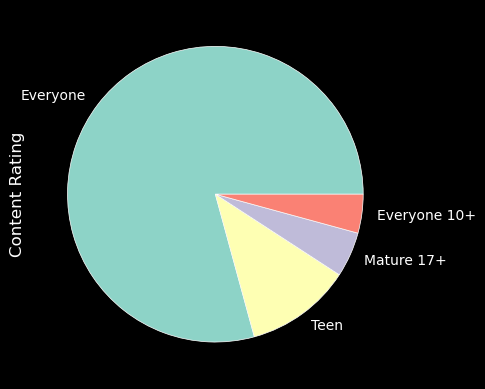

In [ ]:
data['Content Rating'].value_counts().plot.pie()
plt.show()

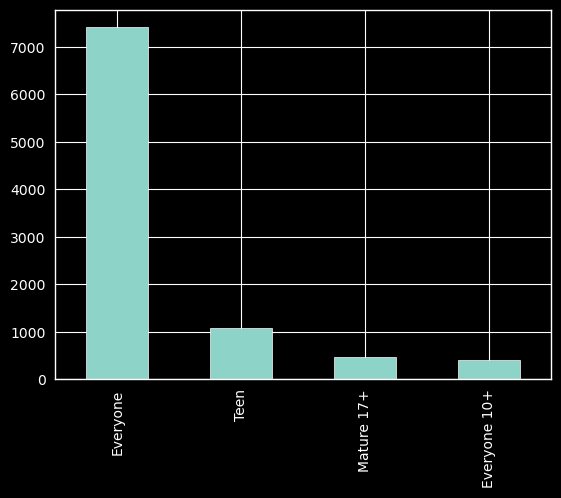

In [ ]:
data['Content Rating'].value_counts().plot.bar()
plt.show()

Scatterplots are perhaps one of the most commonly used as well one of the most powerful visualisations you can use in the field of machine learning. They are pretty crucial in revealing relationships between the data points and you can generally deduce some sort of trends in the data with the help of a scatter plot. - They're pretty useful in regression problems to check whether a linear trend exists in the data or not. **Note**: You'll be studying about both Regression and Clustering in greater detail in the machine learning modulesYou'll be using **sns.jointplot()** for creating a scatter plot. Check out its documentation:
https://seaborn.pydata.org/generated/seaborn.jointplot.html

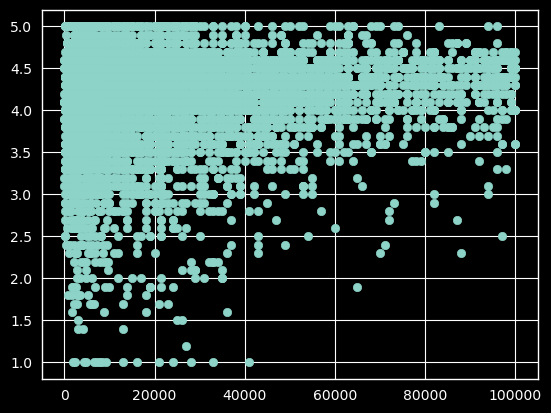

In [ ]:
# Bivariate Analysis
plt.scatter(data.Size, data.Rating)
plt.show()

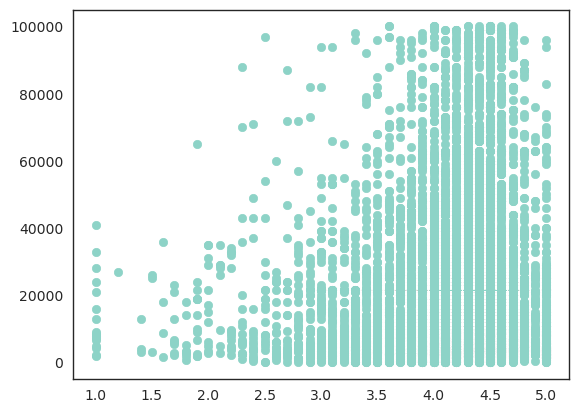

In [ ]:
sns.set_style("white")
plt.scatter(data.Rating, data.Size)
plt.show()

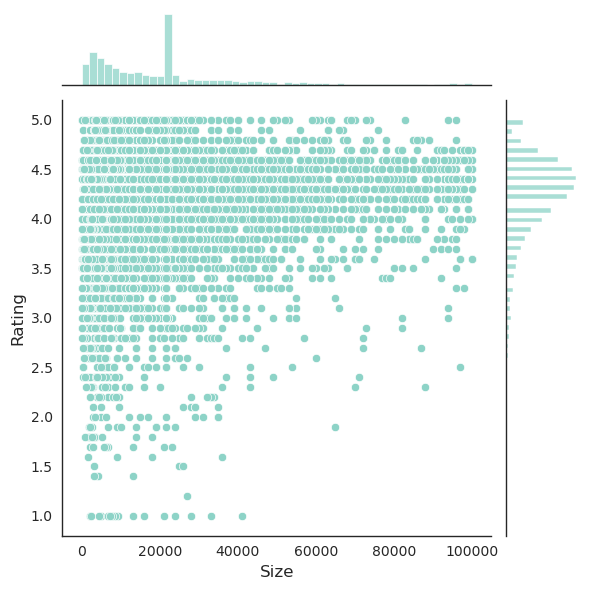

In [ ]:
sns.jointplot(x = 'Size', y = 'Rating', data = data)
plt.show()

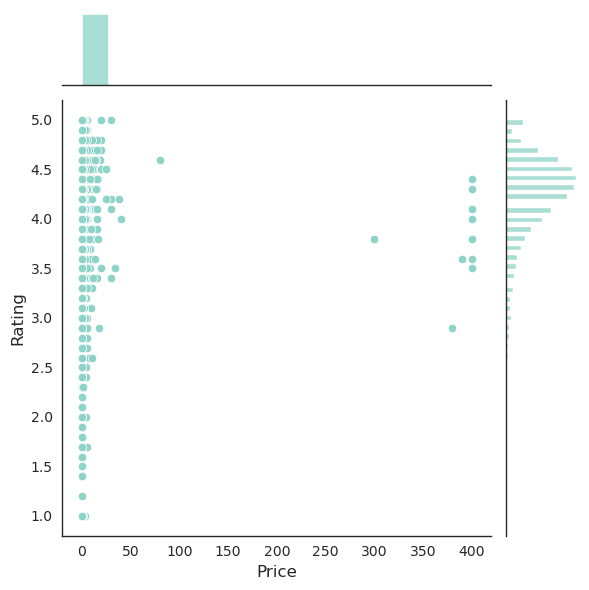

In [ ]:
sns.jointplot(x = 'Price', y = 'Rating', data = data)
plt.show()

**Reg Plots**

- These are an extension to the jointplots, where a regression line is added to the view

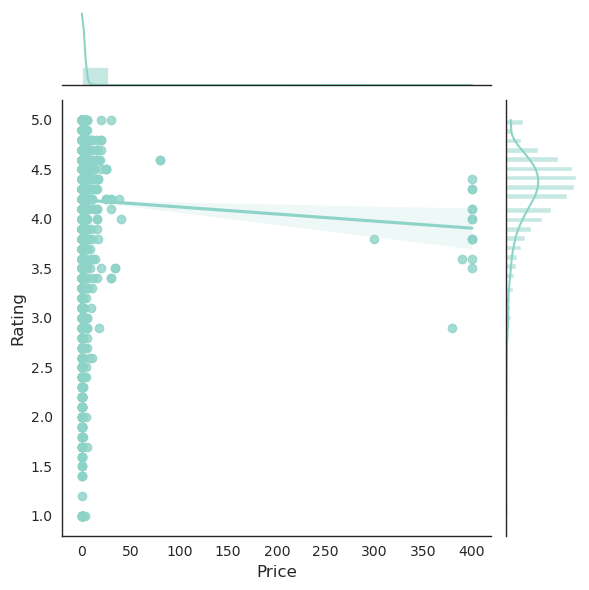

In [ ]:
sns.jointplot(x = 'Price', y = 'Rating', data = data, kind = 'reg')
plt.show()

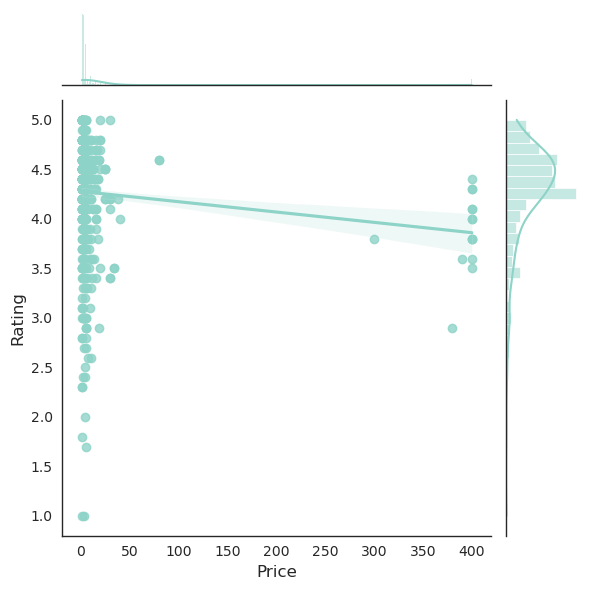

In [ ]:
sns.jointplot(x = 'Price', y = 'Rating', data = data[data.Price>0], kind = 'reg')
plt.show()

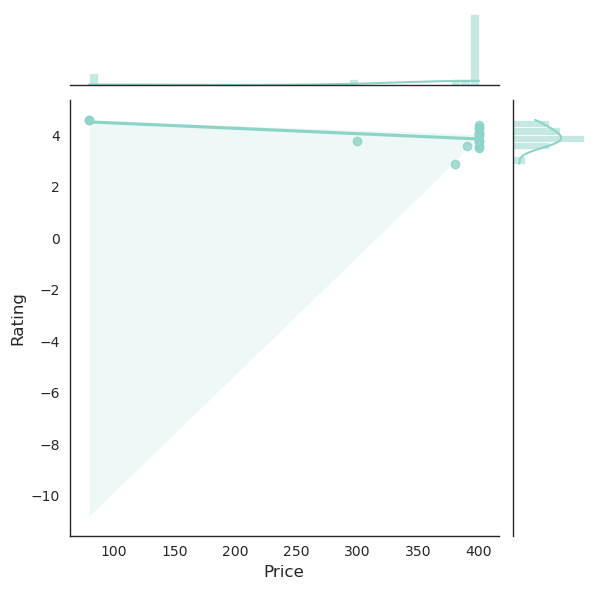

In [ ]:
sns.jointplot(x = 'Price', y = 'Rating', data = data[data.Price>50], kind = 'reg')
plt.show()

**Pair Plots**
 - When you have several numeric variables, making multiple scatter plots becomes rather tedious. Therefore, a pair plot visualisation is preferred where all the scatter plots are in a single view in the form of a matrix
 - For the non-diagonal views, it plots a **scatter plot** between 2 numeric variables
 - For the diagonal views, it plots a **histogram** Pair Plots help in identifying the trends between a target variable and the predictor variables pretty quickly. For example, say you want to predict how your company’s profits are affected by three different factors. In order to choose which you created a pair plot containing profits and the three different factors as the variables. Here are the scatterplots of profits vs the three variables that you obtained from the pair plot. You'll be using **sns.pairplot()** for this visualisation. Check out its official documentation:https://seaborn.pydata.org/generated/seaborn.pairplot.html

<function matplotlib.pyplot.plot(*args, scalex=True, scaley=True, data=None, **kwargs)>

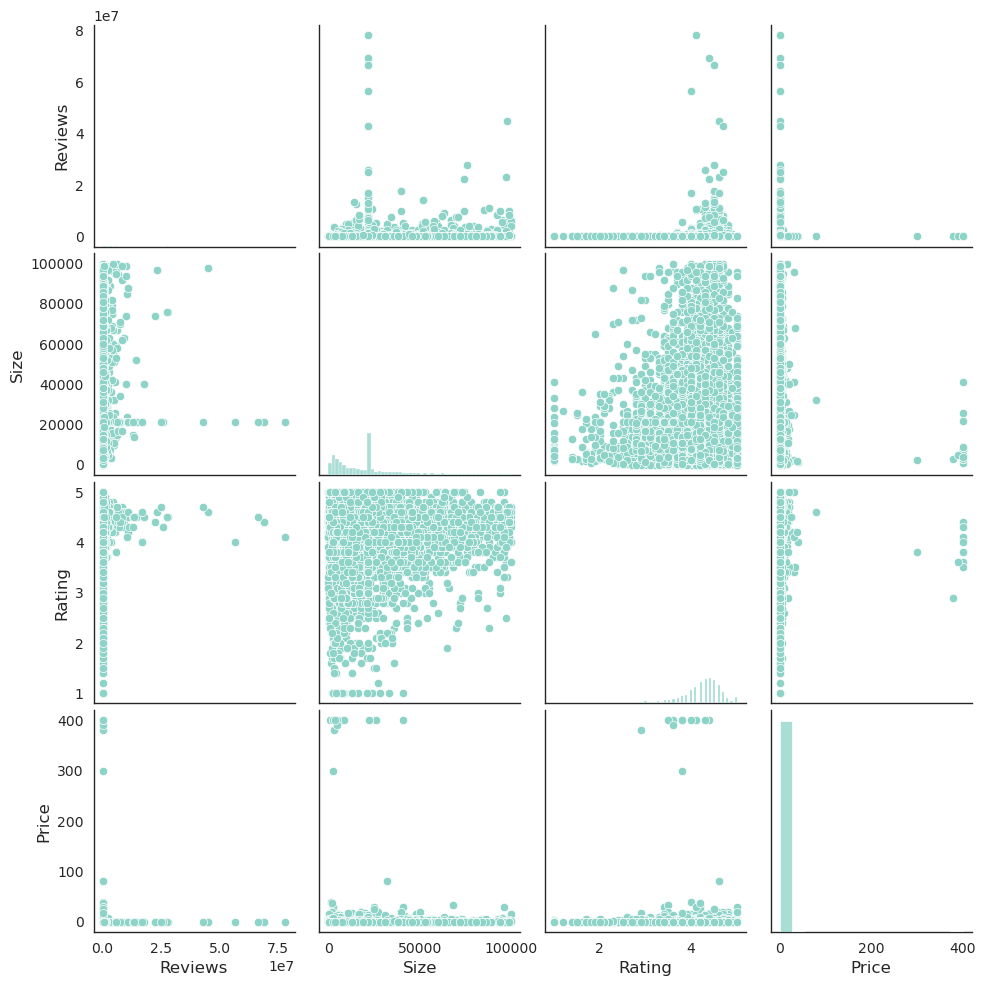

In [ ]:
#Multivariate Analysis
sns.pairplot(data[["Reviews","Size","Rating","Price"]])
plt.plot

<Axes: xlabel='Content Rating'>

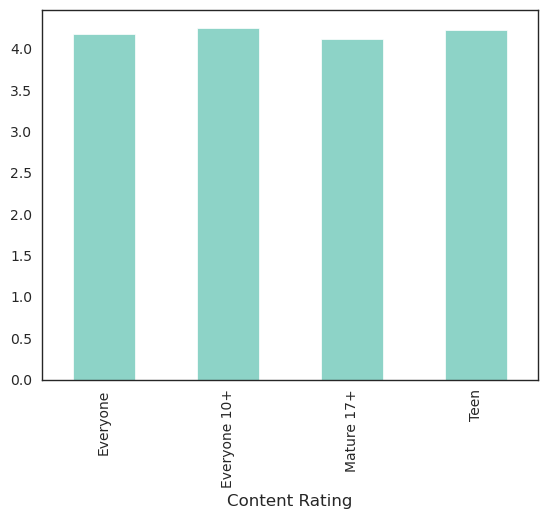

In [ ]:
data.groupby(["Content Rating"])["Rating"].mean().plot.bar()

- Here, you'll be using bar charts once again, this time using the **sns.barplot()** function. Check out its official documentation:https://seaborn.pydata.org/generated/seaborn.barplot.html
- You can modify the **estimator** parameter to change the aggregation value of your barplot

<Axes: xlabel='Content Rating'>

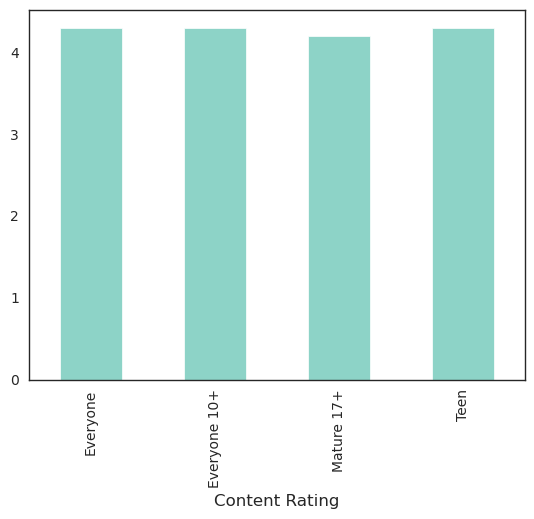

In [ ]:
data.groupby(["Content Rating"])["Rating"].median().plot.bar()

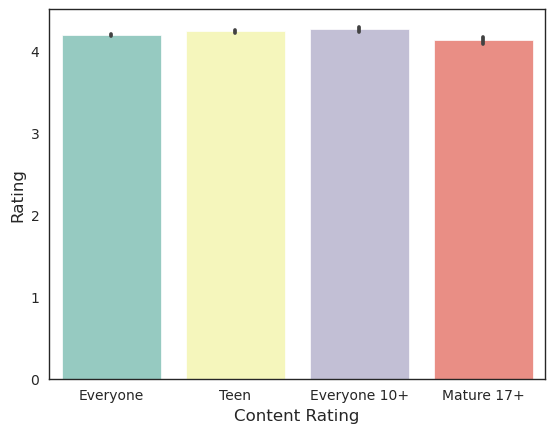

In [ ]:
sns.barplot(data = data , x = 'Content Rating', y= 'Rating')
plt.show()

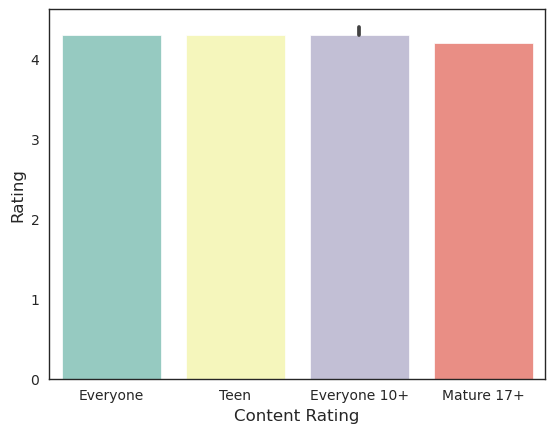

In [ ]:
sns.barplot(data = data , x = 'Content Rating', y= 'Rating', estimator = np.median)
plt.show()

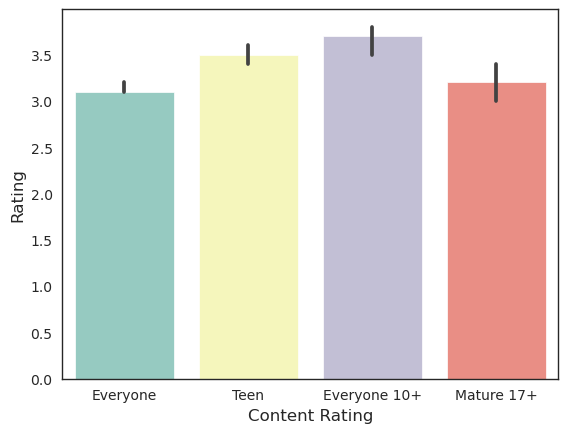

In [ ]:
sns.barplot(data = data , x = 'Content Rating', y= 'Rating', estimator = lambda x: np.quantile(x, 0.05))
plt.show()

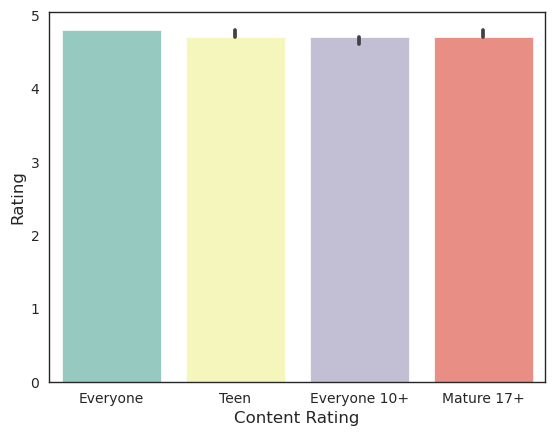

In [ ]:
sns.barplot(data = data , x = 'Content Rating', y= 'Rating', estimator = lambda x: np.quantile(x, 0.95))
plt.show()

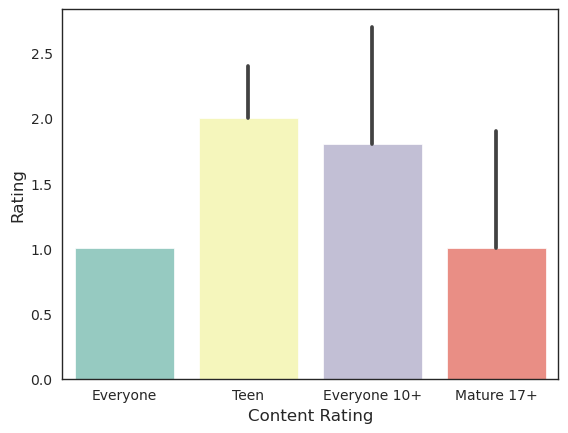

In [ ]:
sns.barplot(data = data , x = 'Content Rating', y= 'Rating', estimator = np.min)
plt.show()

__Box Plots Revisited__

- Apart from outlier analysis, box plots are great at comparing the spread and analysing a numerical variable across several categories
- Here you'll be using **sns.boxplot()** function to plot the visualisation. Check out its documentation: https://seaborn.pydata.org/generated/seaborn.boxplot.html




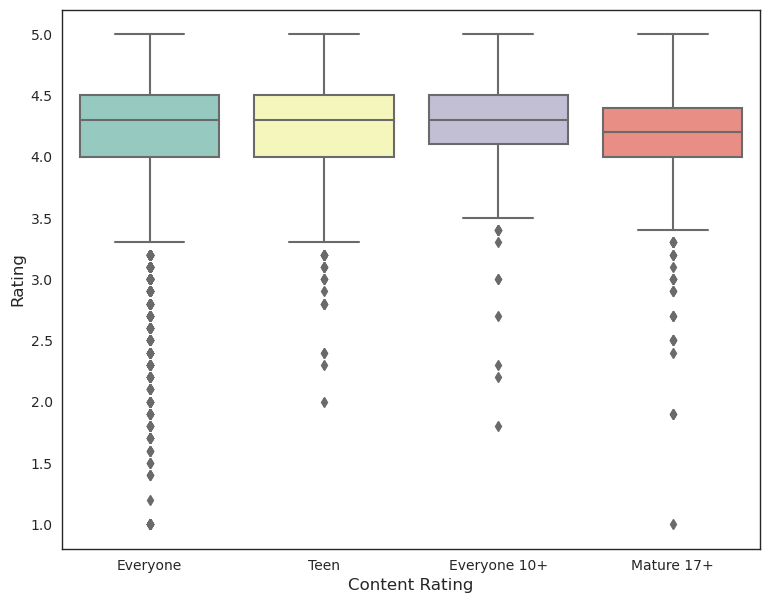

In [ ]:
plt.figure(figsize=[9,7])
sns.boxplot(x = 'Content Rating', y = 'Rating', data = data)
plt.show()

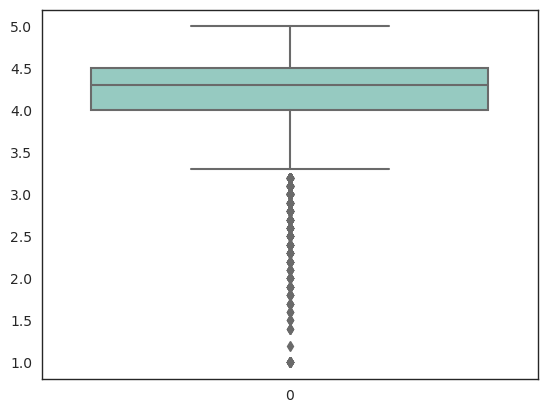

In [ ]:
sns.boxplot(data.Rating)
plt.show()

In [ ]:
# To Plot a box plot of Ratings across the 4 most popular Genres
data['Genres'].value_counts()

Tools                      732
Entertainment              533
Education                  468
Action                     358
Productivity               351
                          ... 
Parenting;Brain Games        1
Card;Brain Games             1
Tools;Education              1
Entertainment;Education      1
Strategy;Creativity          1
Name: Genres, Length: 115, dtype: int64

In [ ]:
c = ['Tools','Entertainment','Medical','Education']
data1= data[data['Genres'].isin(c)]

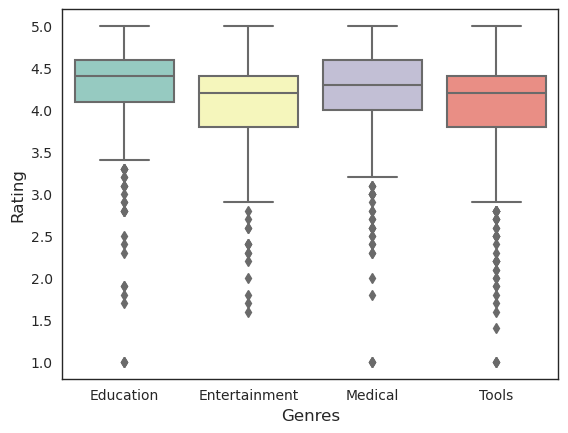

In [ ]:
sns.boxplot(x = data1['Genres'], y = data.Rating)
plt.show()

#### Heat Maps
Heat mapsutilise the concept of using colours and colour intensities to visualise a range of values. You must have seen heat maps in cricket or football broadcasts on television to denote the players’ areas of strength and weakness.- In python, you can create a heat map whenever you have a rectangular grid or table of numbers analysing any two features.- You'll be using **sns.heatmap()** to plot the visualisation. Checkout its official documentation :https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [ ]:
##Ratings vs Size vs Content Rating

##Prepare buckets for the Size column using pd.qcut
data['Size_Bucket'] = pd.qcut(data.Size, [0, 0.2, 0.4, 0.6, 0.8, 1], ["VL","L","M","H","VH"])

In [ ]:
##Create a pivot table for Size_buckets and Content Rating with values set to Rating
data.head()
pd.pivot_table(data=data, index="Content Rating", columns="Size_Bucket", values="Rating")

Size_Bucket,VL,L,M,H,VH
Content Rating,,,,,
Everyone,4.112653,4.167516,4.254010,4.164042,4.220790
Everyone 10+,4.189474,4.251282,4.253153,4.226761,4.283439
Mature 17+,4.112281,4.057292,4.098592,4.174603,4.194175
Teen,4.198165,4.221893,4.207101,4.228462,4.276855


In [ ]:
##Change the aggregation to median
pd.pivot_table(data=data, index="Content Rating", columns="Size_Bucket", values="Rating", aggfunc=np.median)

Size_Bucket,VL,L,M,H,VH
Content Rating,,,,,
Everyone,4.2,4.3,4.3,4.30,4.3
Everyone 10+,4.1,4.3,4.3,4.30,4.4
Mature 17+,4.3,4.2,4.2,4.20,4.2
Teen,4.3,4.3,4.3,4.25,4.3


In [ ]:
##Change the aggregation to 20th percentile
pd.pivot_table(data=data,index="Content Rating",columns="Size_Bucket",values="Rating",aggfunc=lambda x: np.quantile(x,0.2))

Size_Bucket,VL,L,M,H,VH
Content Rating,,,,,
Everyone,3.80,3.80,4.1,3.8,4.00
Everyone 10+,3.86,4.06,4.1,4.0,4.02
Mature 17+,3.42,3.60,4.0,3.9,4.00
Teen,3.80,3.90,4.0,4.0,4.00


In [ ]:
##Store the pivot table in a separate variable
res = pd.pivot_table(data=data,index="Content Rating",columns="Size_Bucket",values="Rating",aggfunc=lambda x: np.quantile(x,0.2))

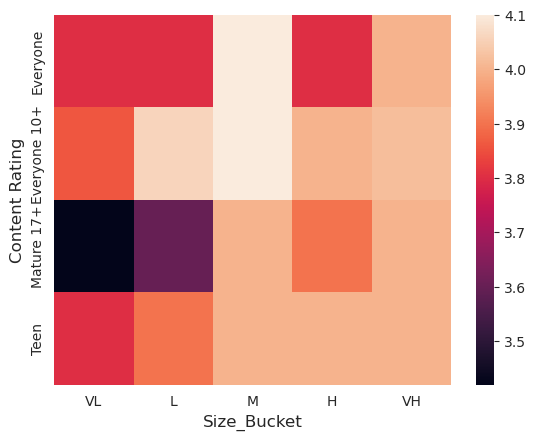

In [ ]:
##Plot a heat map
sns.heatmap(res)
plt.show()

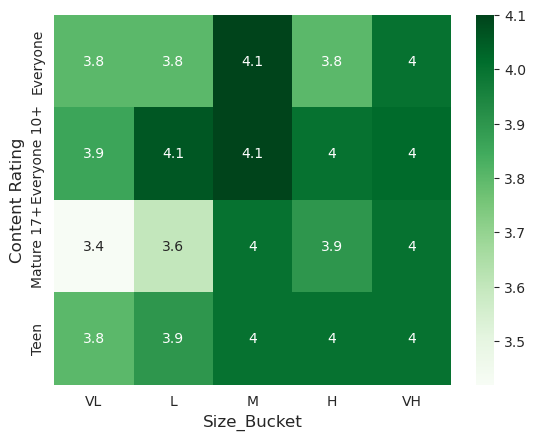

In [ ]:
##Apply customisations
sns.heatmap(res, cmap = "Greens", annot=True)
plt.show()

In [ ]:
data.dtypes

App                 object
Category            object
Rating             float64
Reviews              int32
Size               float64
Installs             int64
Type                object
Price              float64
Content Rating      object
Genres              object
Last Updated        object
Current Ver         object
Android Ver         object
Size_Bucket       category
dtype: object

#### Line Plots
- A line plot tries to observe trends using time dependent data.
-  For this part, you'll be using **pd.to_datetime()** function. Check out its documentation:https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html


In [ ]:
## Extract the month from the Last Updated Date
data['Last Updated'].head()

0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
3        June 8, 2018
4       June 20, 2018
Name: Last Updated, dtype: object

In [ ]:
data['updated_month'] = pd.to_datetime(data['Last Updated']).dt.month

In [ ]:
## Find the average Rating across all the months
data.groupby(['updated_month'])['Rating'].mean()

updated_month
1     4.142892
2     4.094048
3     4.110766
4     4.154600
5     4.161031
6     4.184372
7     4.249206
8     4.292963
9     4.042636
10    4.016460
11    4.112298
12    4.071006
Name: Rating, dtype: float64

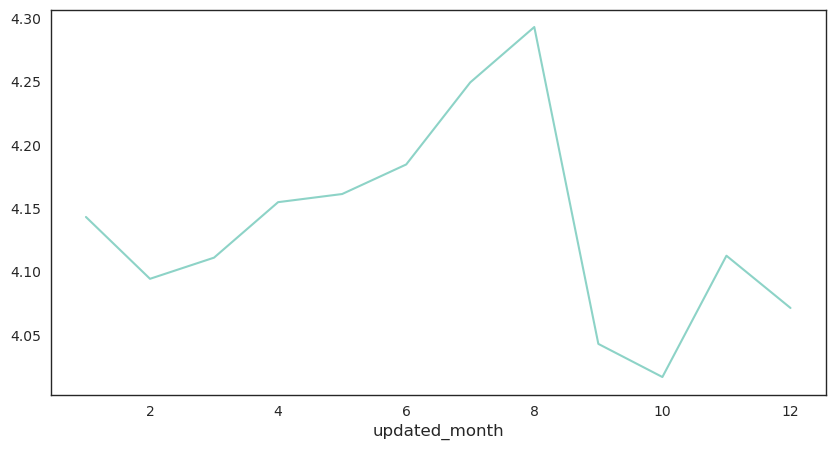

In [ ]:
## Plot a line graph
plt.figure(figsize=[10,5])
data.groupby(['updated_month'])['Rating'].mean().plot()
plt.show()

#### Stacked Bar Charts
- A stacked bar chart breaks down each bar of the bar chart on the basis of a different category


In [ ]:
## Create a pivot table for Content Rating and updated Month with the values set to Installs
pd.pivot_table(data=data, values="Installs", index="updated_month", columns="Content Rating", aggfunc=sum)

Content Rating,Everyone,Everyone 10+,Mature 17+,Teen
updated_month,,,,
1,1025487390,105282000,9701210,44159010
2,945372005,19821000,13021500,39597710
3,1045380520,30322510,9111100,99850310
4,2593371280,23300000,5259000,271619410
5,5431097800,128173500,110140100,562689600
6,6157183505,1367727100,155257200,505716600
7,46991121780,9726556000,1739491910,15983556800
8,46490943320,1715821000,3462981700,16997855650
9,410340410,24931100,2201010,22483100


In [ ]:
##Store the table in a separate variable
monthly = pd.pivot_table(data=data, values="Installs", index="updated_month", columns="Content Rating", aggfunc=sum)

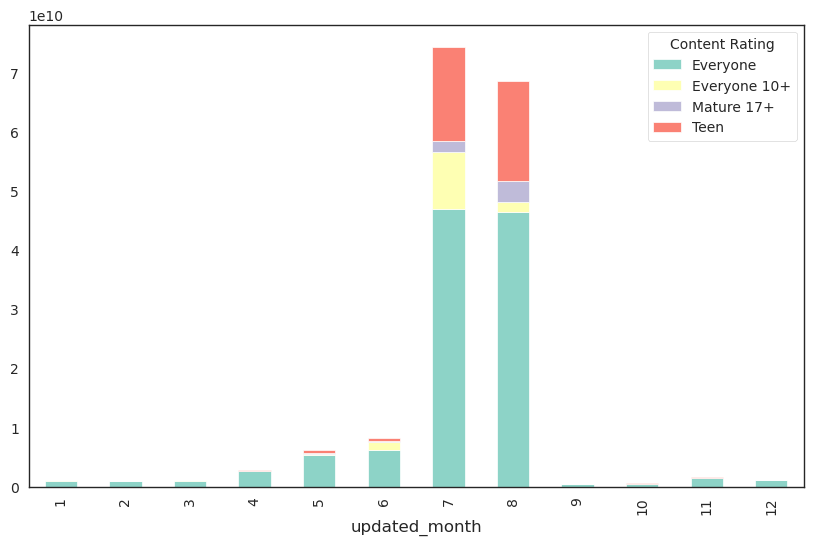

In [ ]:
##Plot the stacked bar chart.
monthly.plot(kind="bar", stacked="True", figsize=[10,6])
plt.show()

In [ ]:
##Plot the stacked bar chart again wrt to the proportions.
monthly_perc = monthly[["Everyone","Everyone 10+","Mature 17+","Teen"]].apply(lambda x: x/x.sum(), axis=1)

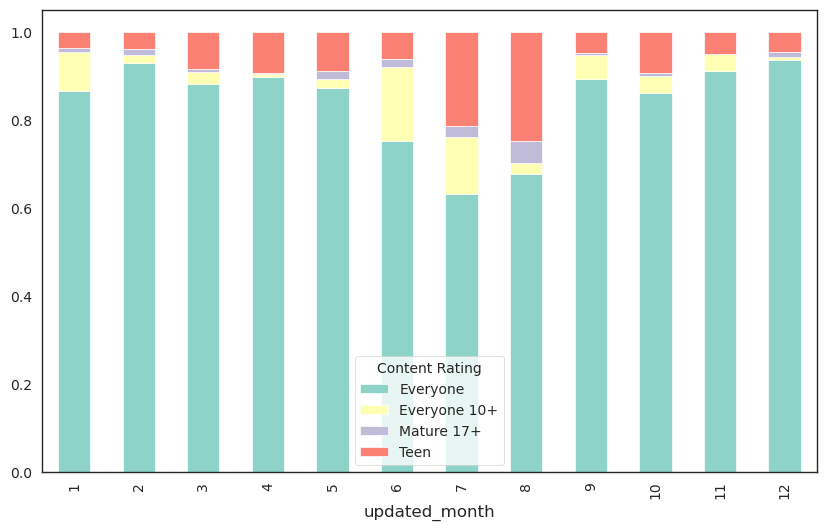

In [ ]:
monthly_perc.plot(kind="bar", stacked="True", figsize=[10,6])
plt.show()

#### Plotly
Plotly is a Python library used for creating interactive visual charts. You can take a look at how you can use it to create aesthetic looking plots with a lot of user-friendly functionalities like hover, zoom, etc.
Check out this link for installation and documentation:https://plot.ly/python/getting-started/
#Install plotly
!pip install plotly

In [ ]:
#Take the table you want to plot in a separate variable
res = data.groupby(["updated_month"])[['Rating']].mean()
res.reset_index(inplace=True)

In [ ]:
res

,updated_month,Rating
0,1,4.142892
1,2,4.094048
2,3,4.110766
3,4,4.154600
4,5,4.161031
5,6,4.184372
6,7,4.249206
7,8,4.292963
8,9,4.042636
9,10,4.016460


In [ ]:
#Import the plotly libraries
import plotly.express as px

In [ ]:
#Prepare the plot
fig = px.line(res, x="updated_month",y="Rating",title="Montly average rating")
fig.show()

NameError: name 'px' is not defined